In [30]:
from skimage import io, color, measure
import os
from PIL import Image
import numpy as np
import pandas as pd

In [36]:

def get_entropy(image_path):
    try:
        # 使用PIL打开图像，确保格式正确
        pil_image = Image.open(image_path)
        
        # 转换为灰度图像
        if pil_image.mode in ('RGBA', 'LA', 'P'):
            # 对于有透明度的图像，先转换为RGB再转灰度
            gray_image = pil_image.convert('RGB').convert('L')
            print(f"处理 {pil_image.mode} 图像: 转换为灰度")
        elif pil_image.mode == 'RGB':
            gray_image = pil_image.convert('L')
            print(f"处理 {pil_image.mode} 图像: 转换为灰度")
        elif pil_image.mode == 'L':
            gray_image = pil_image  # 已经是灰度
            print(f"直接使用 {pil_image.mode} 图像")
        else:
            # 其他模式先转换为RGB再转灰度
            gray_image = pil_image.convert('RGB').convert('L')
            print(f"处理 {pil_image.mode} 图像: 转换为灰度")
        
        # 转换为numpy数组
        gray_array = np.array(gray_image)
        
        # 计算香农熵
        entropy = measure.shannon_entropy(gray_array)

        return entropy
    
    except Exception as e:
        print(f"处理图像时出错: {e}")
        return None

In [25]:
file_path = r'E:\Desktop\data\edit_start'

file_dict = {}
file_dict['image'] = []
file_dict['entropy'] = []
for i in os.listdir(file_path):
    path =os.path.join(file_path,i)
    file_dict['image'].append(path)
    file_dict['entropy'].append(get_entropy(path))



<Axes: >

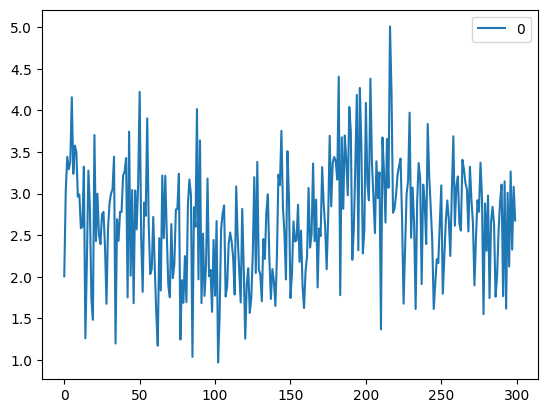

In [32]:
test_file_path = file_dict['entropy']

pd.DataFrame(test_file_path).plot.line()

In [ ]:
file_path = r'E:\Desktop\data\edit_end'

file_dict_end = {}
file_dict_end['image'] = []
file_dict_end['entropy'] = []
for i in os.listdir(file_path):
    path =os.path.join(file_path,i)
    file_dict_end['image'].append(path)
    file_dict_end['entropy'].append(get_entropy(path))

<Axes: >

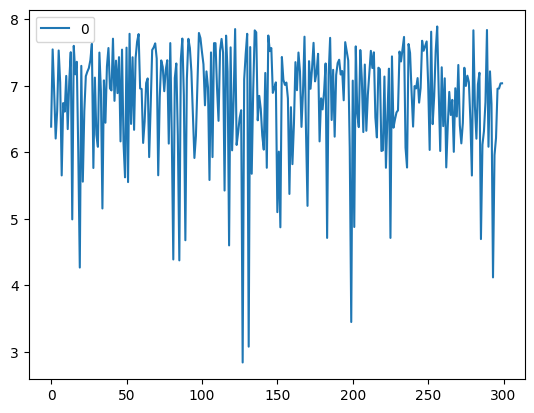

In [38]:
test_file_path_2 = file_dict_end['entropy']

pd.DataFrame(test_file_path_2).plot.line()